# 1000Hz Motor Imagery EEG Evaluation Walkthrough

1. Load calibration / evaluation / true_y files
2. Inspect `mrk.pos` trial onsets and labels
3. Convert calibration trials into sample-level labels: `-1 / 0 / 1`
4. Visualize raw signals, band-pass filtered signals, and Laplacian-filtered signals
5. Inspect how sliding windows are created
6. Compare the minimal and preprocessed pipelines using MSE, accuracy, and confusion matrices

By default, this notebook runs subject `e`. To inspect another subject, change `subject = "e"` to any subject from `a` to `g` in the setup cell below.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import loadmat
from sklearn import metrics

from evaluate_1000hz_pipeline import (
    CALIB_DIR,
    EVAL_DIR,
    TRUE_DIR,
    LABELS,
    bandpass,
    high_laplacian,
    load_subject,
    run_pipeline_for_subject,
)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

subject = "e"
data = load_subject(subject)

print(f"subject: {subject}")
print(f"fs: {data.fs} Hz")
print(f"calibration data: {data.train_data.shape}")
print(f"evaluation data : {data.eval_data.shape}")
print(f"true_y length    : {len(data.true_y)}")
print(f"non-NaN true_y   : {np.sum(~np.isnan(data.true_y))}")

subject: e
fs: 1000 Hz
calibration data: (1903295, 59)
evaluation data : (2384534, 59)
true_y length    : 2384534
non-NaN true_y   : 1749485


## 1. Inspect Trial Onsets in the Calibration File

`mrk.pos` stores the starting sample of each motor imagery trial. `mrk.y` stores the label of that trial, usually `-1` or `1`. This section prints the first few trial onset samples and their labels.


In [2]:
calib_path = CALIB_DIR / f"BCICIV_calib_ds1{subject}_1000Hz.mat"
mat = loadmat(calib_path)
mrk = mat["mrk"]
nfo = mat["nfo"]

cue_positions = np.asarray(mrk["pos"][0, 0]).ravel().astype(int)
cue_labels = np.asarray(mrk["y"][0, 0]).ravel().astype(int)
channel_names = [str(x[0]) for x in np.asarray(nfo["clab"][0, 0]).ravel()]

print("number of calibration trials:", len(cue_positions))
print("first 10 cue positions:", cue_positions[:10])
print("first 10 cue labels   :", cue_labels[:10])
print("label counts:", dict(zip(*np.unique(cue_labels, return_counts=True))))
print("first channels:", channel_names[:12])

number of calibration trials: 200
first 10 cue positions: [20921 28921 36922 44922 52922 60922 68923 76923 84923 92924]
first 10 cue labels   : [ 1  1 -1  1 -1 -1 -1 -1 -1  1]
label counts: {-1: 100, 1: 100}
first channels: ['AF3', 'AF4', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'FC5', 'FC3', 'FC1']


In [4]:
# `nfo` contains metadata from the calibration file.
# It is a MATLAB struct with fields:
# - fs: sampling frequency
# - classes: cue classes / labels
# - clab: channel labels
# - xpos, ypos: electrode positions
print("nfo fields:", nfo.dtype.names)
print("sampling frequency (fs):", np.asarray(nfo["fs"][0, 0]).item())
print("classes:", [str(x[0]) for x in np.asarray(nfo["classes"][0, 0]).ravel()])
print("number of channels:", len(channel_names))
print("first 12 channel names:", channel_names[:12])
print("first 12 xpos values:", np.asarray(nfo["xpos"][0, 0]).ravel()[:12])
print("first 12 ypos values:", np.asarray(nfo["ypos"][0, 0]).ravel()[:12])

nfo fields: ('fs', 'classes', 'clab', 'xpos', 'ypos')
sampling frequency (fs): 1000
classes: ['left', 'right']
number of channels: 59
first 12 channel names: ['AF3', 'AF4', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'FC5', 'FC3', 'FC1']
first 12 xpos values: [-0.20109028  0.20109028 -0.48547489 -0.32894737 -0.16535231  0.
  0.16535231  0.32894737  0.48547489 -0.60591541 -0.39919579 -0.19765935]
first 12 ypos values: [0.68656518 0.68656518 0.52547424 0.46520183 0.43208641 0.421549
 0.43208641 0.46520183 0.52547424 0.27165704 0.23384348 0.21394494]


## 2. How Trial Onsets Become Sample-Level Labels

The pipeline converts calibration labels into a continuous sample-level label vector using the following logic:

- All calibration samples are initialized as `0`
- For each trial, the interval from `mrk.pos` to `mrk.pos + 4 seconds` is assigned the trial label, either `-1` or `1`
- All non-motor-imagery intervals remain `0`

This makes the training labels closer to the evaluation `true_y` format, where every sample can be labeled as `-1 / 0 / 1`.


sample-level training label counts: {-1: 400000, 0: 1103295, 1: 400000}


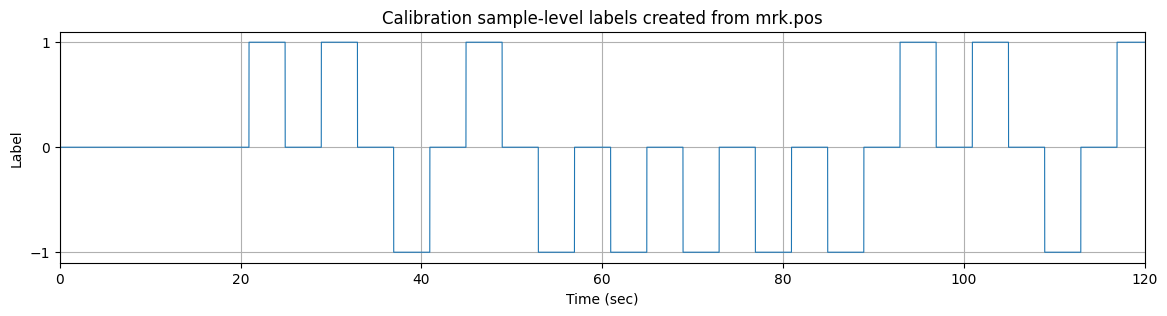

In [5]:
fs = data.fs
trial_seconds = 4
trial_len = trial_seconds * fs

train_y_sample = np.zeros(data.train_data.shape[0], dtype=int)
for pos, label in zip(cue_positions, cue_labels):
    train_y_sample[pos : min(pos + trial_len, len(train_y_sample))] = label

print("sample-level training label counts:", dict(zip(*np.unique(train_y_sample, return_counts=True))))

t = np.arange(len(train_y_sample)) / fs
plt.figure(figsize=(14, 3))
plt.plot(t, train_y_sample, lw=0.8)
plt.xlabel("Time (sec)")
plt.ylabel("Label")
plt.yticks([-1, 0, 1])
plt.title("Calibration sample-level labels created from mrk.pos")
plt.xlim(0, min(t[-1], 120))
plt.show()

## 3. Visualize a Raw EEG Segment and Trial Onsets

The next plot uses `C3 / Cz / C4` if these channels are available. If not, it automatically falls back to the first three channels. Red dashed vertical lines indicate trial onset positions from `mrk.pos`.


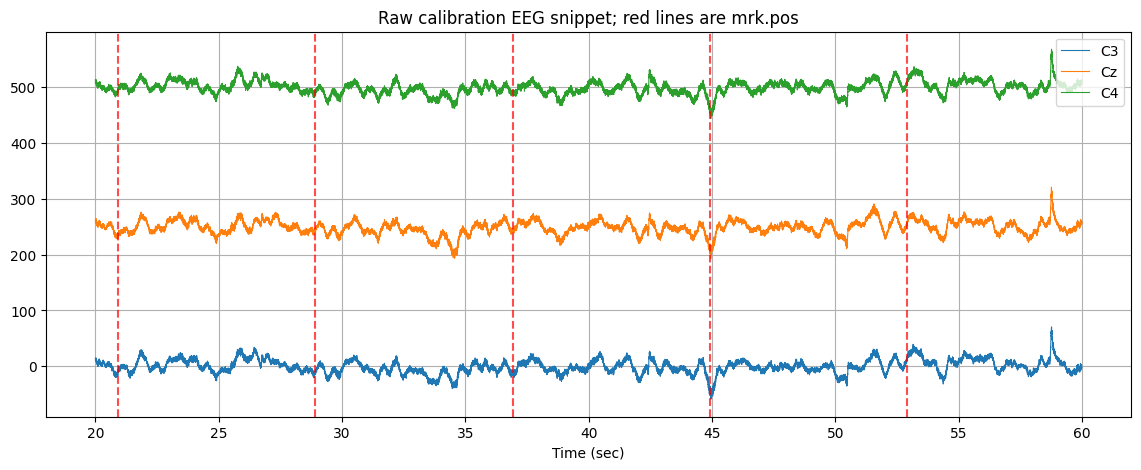

In [8]:
wanted = ["C3", "Cz", "C4"]
channels = [channel_names.index(ch) for ch in wanted if ch in channel_names]
if len(channels) < 3:
    channels = [0, 1, 2]
selected_names = [channel_names[i] for i in channels]

start_sec = 20
duration_sec = 40
start = start_sec * fs
end = start + duration_sec * fs
time = np.arange(start, end) / fs

plt.figure(figsize=(14, 5))
offset = 250
for rank, ch in enumerate(channels):
    plt.plot(time, data.train_data[start:end, ch] + rank * offset, label=selected_names[rank], lw=0.8)

for pos in cue_positions[(cue_positions >= start) & (cue_positions <= end)]:
    plt.axvline(pos / fs, color="red", ls="--", alpha=0.7)

plt.xlabel("Time (sec)")
plt.title("Raw calibration EEG snippet; red lines are mrk.pos")
plt.legend()
plt.show()

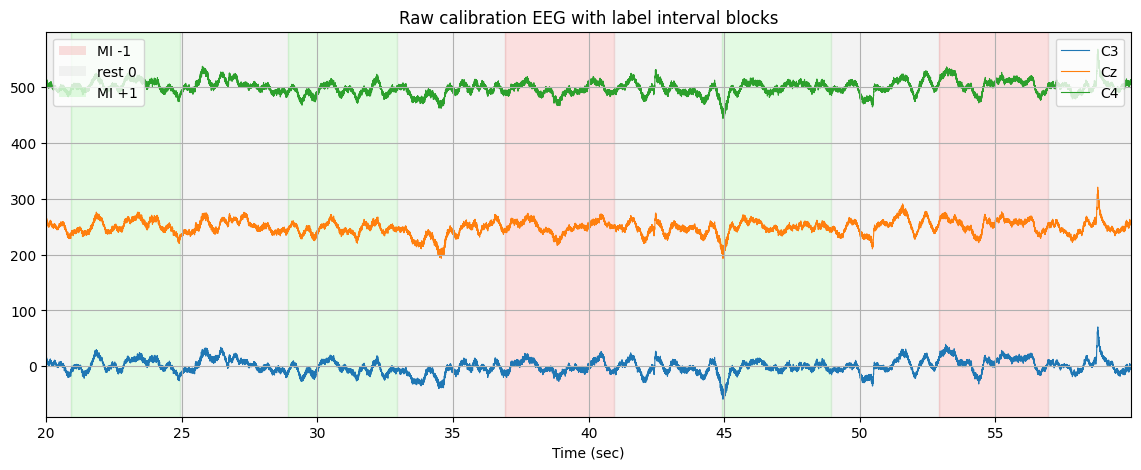

In [9]:
from matplotlib.patches import Patch

segment_labels = train_y_sample[start:end]
boundaries = np.concatenate(
    ([0], np.flatnonzero(segment_labels[:-1] != segment_labels[1:]) + 1, [len(segment_labels)])
)

label_colors = {-1: "lightcoral", 0: "lightgray", 1: "lightgreen"}
label_names = {-1: "MI -1", 0: "rest 0", 1: "MI +1"}

fig, ax = plt.subplots(figsize=(14, 5))

for s, e in zip(boundaries[:-1], boundaries[1:]):
    label = int(segment_labels[s])
    ax.axvspan((start + s) / fs, (start + e) / fs, color=label_colors[label], alpha=0.25, zorder=0)

for rank, ch in enumerate(channels):
    ax.plot(
        time,
        data.train_data[start:end, ch] + rank * offset,
        label=selected_names[rank],
        lw=0.8,
        zorder=1,
    )

ax.set_xlabel("Time (sec)")
ax.set_title("Raw calibration EEG with label interval blocks")
ax.set_xlim(time[0], time[-1])

line_legend = ax.legend(loc="upper right")
patches = [Patch(facecolor=color, alpha=0.25, label=label_names[label]) for label, color in label_colors.items()]
ax.add_artist(line_legend)
ax.legend(handles=patches, loc="upper left")

plt.show()

## 4. Signals and Spectrum Before/After Preprocessing

The preprocessed pipeline applies:

```text
raw EEG -> 8-30 Hz bandpass -> High Laplacian -> CSP
```

This section first compares the time-domain waveform before and after band-pass filtering and High Laplacian spatial filtering.


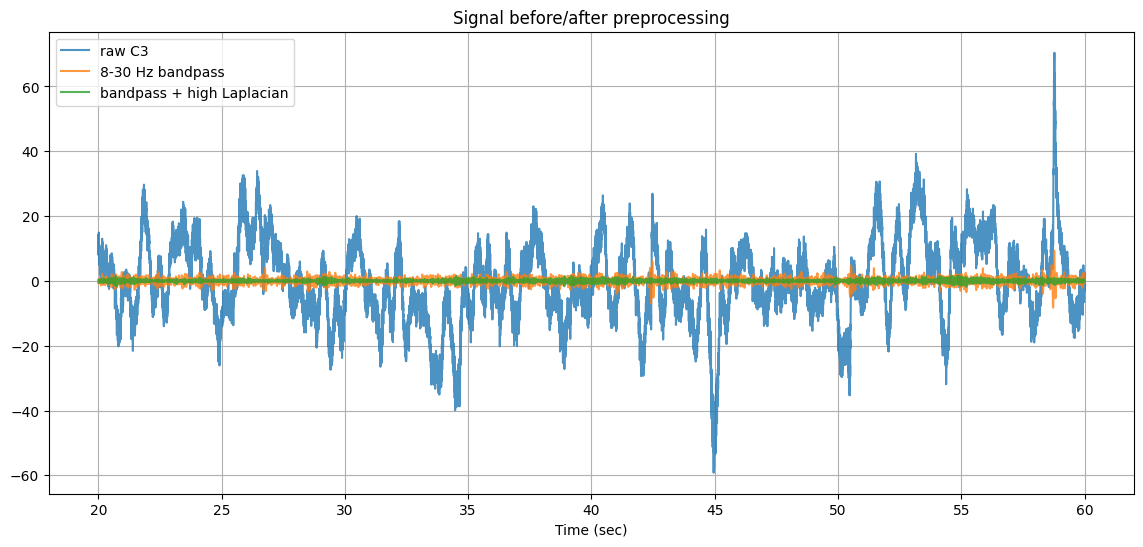

In [10]:
raw = data.train_data
bp = bandpass(raw, fs)
lap = high_laplacian(bp, data.positions)

ch = channels[0]
plt.figure(figsize=(14, 6))
plt.plot(time, raw[start:end, ch], label=f"raw {channel_names[ch]}", alpha=0.8)
plt.plot(time, bp[start:end, ch], label="8-30 Hz bandpass", alpha=0.8)
plt.plot(time, lap[start:end, ch], label="bandpass + high Laplacian", alpha=0.8)
plt.xlabel("Time (sec)")
plt.title("Signal before/after preprocessing")
plt.legend()
plt.show()

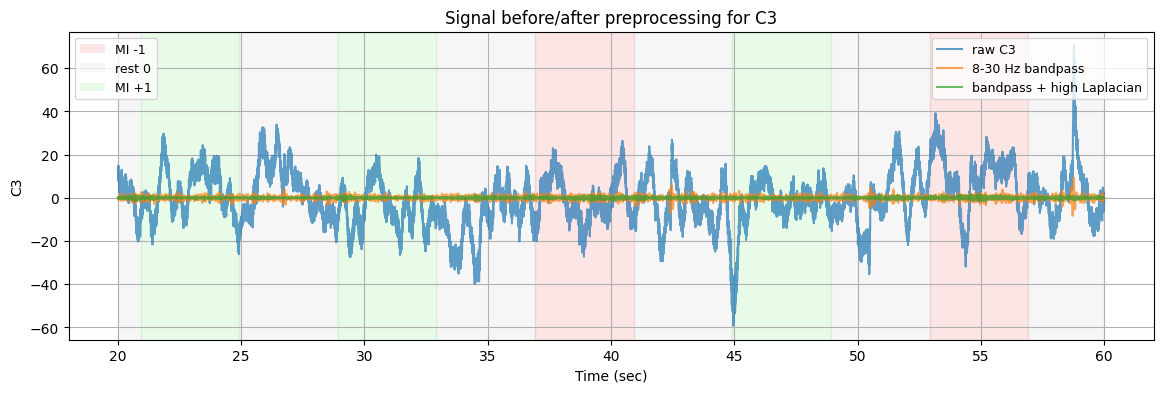

In [11]:
channels = [channel_names.index("C3")] if "C3" in channel_names else [0]
ch_idx = channels[0]
name = channel_names[ch_idx]

fig, ax = plt.subplots(figsize=(14, 4), sharex=True)

ax.plot(time, raw[start:end, ch_idx], label=f"raw {name}", alpha=0.7)
ax.plot(time, bp[start:end, ch_idx], label="8-30 Hz bandpass", alpha=0.7)
ax.plot(time, lap[start:end, ch_idx], label="bandpass + high Laplacian", alpha=0.7)

ax.set_ylabel(name)
ax.set_xlabel("Time (sec)")
ax.set_title("Signal before/after preprocessing for C3")

line_legend = ax.legend(loc="upper right", fontsize=9)
ax.add_artist(line_legend)

segment_labels = train_y_sample[start:end]
boundaries = np.concatenate(
    ([0], np.flatnonzero(segment_labels[:-1] != segment_labels[1:]) + 1, [len(segment_labels)])
)

for s, e in zip(boundaries[:-1], boundaries[1:]):
    label = int(segment_labels[s])
    ax.axvspan((start + s) / fs, (start + e) / fs, color=label_colors[label], alpha=0.2, zorder=0)

legend_patches = [Patch(facecolor=color, alpha=0.2, label=label_names[label]) for label, color in label_colors.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=9)

plt.show()

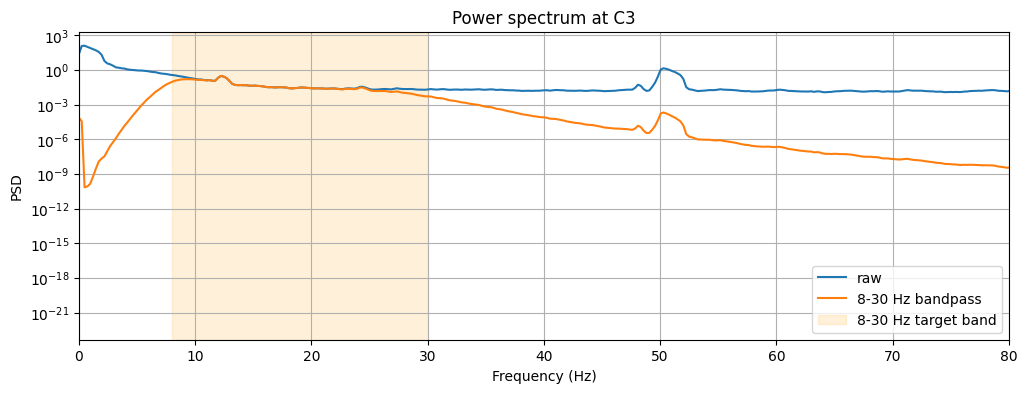

In [12]:
f_raw, p_raw = signal.welch(raw[:, ch], fs=fs, nperseg=4096)
f_bp, p_bp = signal.welch(bp[:, ch], fs=fs, nperseg=4096)

plt.figure(figsize=(12, 4))
plt.semilogy(f_raw, p_raw, label="raw")
plt.semilogy(f_bp, p_bp, label="8-30 Hz bandpass")
plt.axvspan(8, 30, color="orange", alpha=0.15, label="8-30 Hz target band")
plt.xlim(0, 80)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"Power spectrum at {channel_names[ch]}")
plt.legend()
plt.show()

## 5. Sliding Window Configuration

The default setting is:

- window = 1 second
- step = 0.25 seconds
- each window receives the label of its center sample

This is more stable than using a single sample and more suitable for continuous evaluation labels than using one 4-second trial as a single prediction unit.


window samples: 1000
step samples  : 250
number of training windows: 7610
window label counts: {-1: 1600, 0: 4410, 1: 1600}


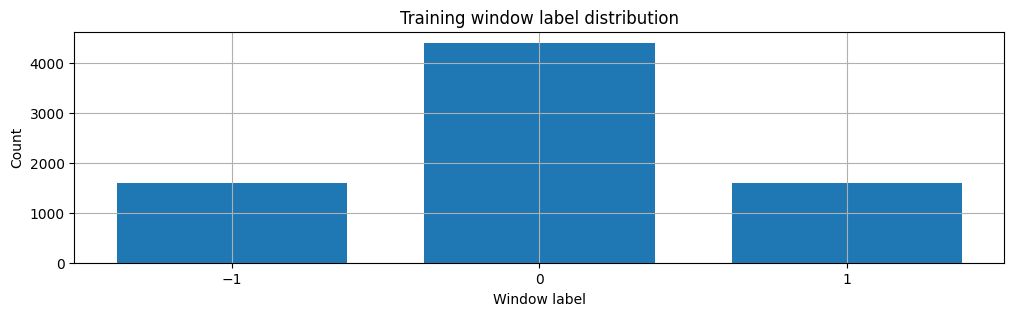

In [13]:
window_seconds = 1.0
step_seconds = 0.25
window = int(window_seconds * fs)
step = int(step_seconds * fs)
starts = np.arange(0, len(train_y_sample) - window + 1, step, dtype=int)
centers = starts + window // 2
window_y = train_y_sample[centers]

print("window samples:", window)
print("step samples  :", step)
print("number of training windows:", len(starts))
print("window label counts:", dict(zip(*np.unique(window_y, return_counts=True))))

plt.figure(figsize=(12, 3))
plt.hist(window_y, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.75)
plt.xticks([-1, 0, 1])
plt.xlabel("Window label")
plt.ylabel("Count")
plt.title("Training window label distribution")
plt.show()

## 6. Run the Minimal and Preprocessed Pipelines, Then Plot Confusion Matrices

This cell trains and evaluates both pipelines on the currently selected subject. Running one subject can take around one minute, depending on the machine and subject file size.


In [15]:
class Args:
    window_seconds = 1.0
    step_seconds = 0.25
    csp_pairs = 2
    random_state = 0
    binary_only = True

args = Args()
results = {}
for mode in ["minimal", "preprocessed"]:
    results[mode] = run_pipeline_for_subject(data, mode, args)
    print(mode, "MSE=", round(results[mode]["mse"], 6), "accuracy=", round(results[mode]["accuracy"], 6))
    print("pred_counts:", results[mode]["pred_counts"])
    print(results[mode]["confusion"])
    print()

minimal MSE= 2.054767 accuracy= 0.486308
pred_counts: {-1: 530366, 1: 341028}
[[262602 179864]
 [267764 161164]]

preprocessed MSE= 0.144766 accuracy= 0.963809
pred_counts: {-1: 441283, 1: 430111}
[[426106  16360]
 [ 15177 413751]]



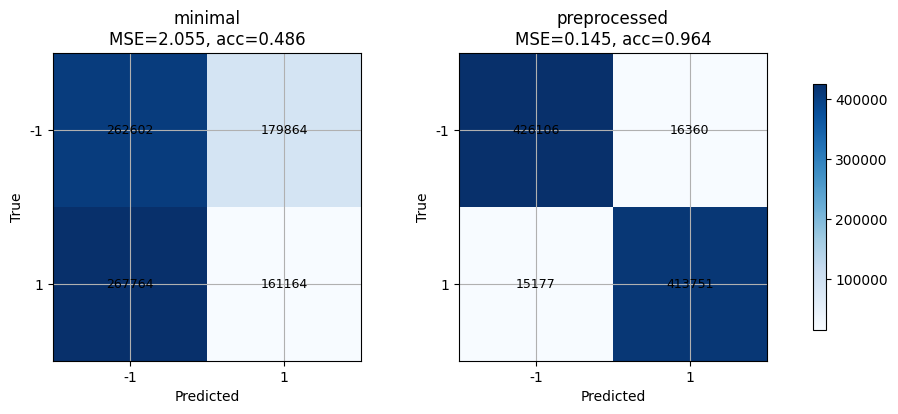

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mode in zip(axes, ["minimal", "preprocessed"]):
    cm = results[mode]["confusion"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{mode}\nMSE={results[mode]['mse']:.3f}, acc={results[mode]['accuracy']:.3f}")
    ax.set_xticks(range(2), np.array([-1,  1]))
    ax.set_yticks(range(2), np.array([-1,  1]))
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

## 7. Summary Plot Across All Subjects

The cell below can run subjects `a-g` and plot a cross-subject MSE comparison. It takes longer, so it is disabled by default. Set `run_all_subjects = True` when you want to run the full comparison.


a minimal 1.604137760875558 0.5989655597811105
a preprocessed 1.405486249347002 0.6486284376632495
b minimal 1.9618283787128195 0.5095429053217951
b preprocessed 1.505371292423982 0.6236571768940046
c minimal 1.933408401294812 0.516647899676297
c preprocessed 1.1493727564999525 0.7126568108750119
d minimal 2.0561717405125335 0.48595706487186663
d preprocessed 0.34160432728430723 0.9145989181789231
e minimal 2.0547674186418545 0.4863081453395364
e preprocessed 0.14476574316554852 0.9638085642086128
f minimal 1.7955264276751735 0.5511183930812067
f preprocessed 1.2397600176057757 0.690059995598556
g minimal 1.6249063069976715 0.5937734232505821
g preprocessed 1.297142166318877 0.6757144584202808


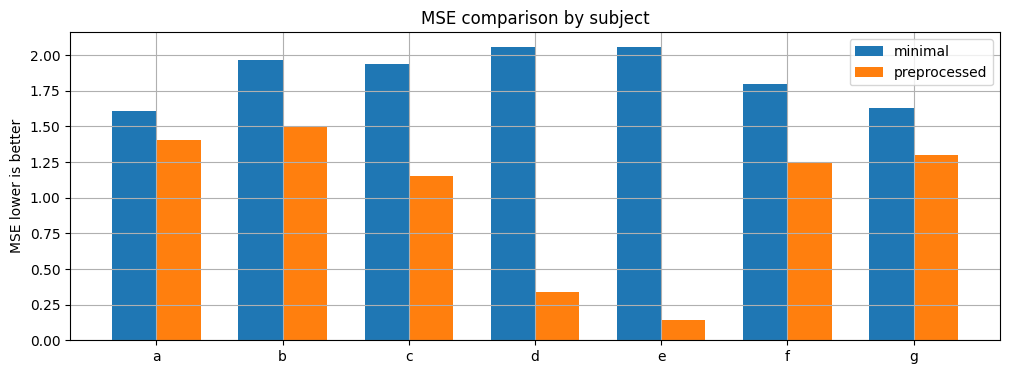

In [24]:
run_all_subjects = True

if run_all_subjects:
    rows = []
    for sub in list("abcdefg"):
        sub_data = load_subject(sub)
        for mode in ["minimal", "preprocessed"]:
            result = run_pipeline_for_subject(sub_data, mode, args)
            rows.append((sub, mode, result["mse"], result["accuracy"]))
            print(sub, mode, result["mse"], result["accuracy"])

    subjects = list("abcdefg")
    x = np.arange(len(subjects))
    width = 0.35
    minimal_mse = [r[2] for r in rows if r[1] == "minimal"]
    pre_mse = [r[2] for r in rows if r[1] == "preprocessed"]

    plt.figure(figsize=(12, 4))
    plt.bar(x - width / 2, minimal_mse, width, label="minimal")
    plt.bar(x + width / 2, pre_mse, width, label="preprocessed")
    plt.xticks(x, subjects)
    plt.ylabel("MSE lower is better")
    plt.title("MSE comparison by subject")
    plt.legend()
    plt.show()
else:
    print("Set run_all_subjects = True to run all subjects.")